# 🩺 Cancer Risk Level Prediction — End-to-End ML Pipeline

**Goal:** Predict patient cancer risk level (`Low` / `Medium` / `High`) from clinical and lifestyle features using multiple classifiers, with final model tuned via Optuna and tracked on MLflow / DagsHub.

**Pipeline Overview:**
1. Environment setup & secret loading
2. Data ingestion from MongoDB
3. Exploratory Data Analysis (EDA)
4. Baseline models — Random Forest & Logistic Regression
5. Handling class imbalance (SMOTE)
6. Optuna hyperparameter tuning — Random Forest
7. Baseline XGBoost (SMOTE pipeline)
8. Optuna tuning — XGBoost (High-recall objective)
9. **Winner:** Optuna-tuned Class-Weighted XGBoost (macro-F1 objective)
10. Save artifacts & MLflow logging
11. Package outputs as ZIP

---
## 🔧 Section 1 — Environment Setup

In [1]:
# ─────────────────────────────────────────────────────────────────────────────
# Install all required packages
# optuna        : Bayesian hyperparameter optimisation
# imbalanced-learn : SMOTE for class imbalance
# xgboost       : Gradient boosting classifier
# mlflow        : Experiment tracking
# pymongo       : MongoDB driver for data ingestion
# dagshub       : Remote MLflow tracking server
# ─────────────────────────────────────────────────────────────────────────────
!pip install -q optuna imbalanced-learn xgboost mlflow pymongo dagshub

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.6/40.6 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 19.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 119.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 122.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 98.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 101.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 263.5/263.5 kB 31.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 331.1/331.1 kB 35.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 18.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 14.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 197.1/197.1 kB 25.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 10.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [2]:
# ─────────────────────────────────────────────────────────────────────────────
# Load secrets from Colab's secure Secret Manager and set environment variables.
# All credentials are stored as Colab secrets — no hard-coded keys here.
# ─────────────────────────────────────────────────────────────────────────────
import os
from google.colab import userdata

# ── MongoDB ───────────────────────────────────────────────────────────────────
os.environ['MONGO_DB_URL'] = userdata.get('MONGO_DB_URL')

# ── MLflow / DagsHub ──────────────────────────────────────────────────────────
USE_DAGSHUB = True  # Set False to log locally inside Colab

if USE_DAGSHUB:
    # Remote DagsHub tracking — experiments are stored on your DagsHub repo
    os.environ['MLFLOW_TRACKING_URI']      = userdata.get('MLFLOW_TRACKING_URI')
    os.environ['MLFLOW_TRACKING_USERNAME'] = userdata.get('MLFLOW_TRACKING_USERNAME')
    os.environ['MLFLOW_TRACKING_PASSWORD'] = userdata.get('MLFLOW_TRACKING_PASSWORD')
else:
    # Local MLflow — logs saved inside the Colab runtime filesystem
    os.environ['MLFLOW_TRACKING_URI'] = f"file://{os.getcwd()}/mlruns"

print('✅ Environment variables set successfully.')
print(f"   MLFLOW_TRACKING_URI = {os.environ['MLFLOW_TRACKING_URI']}")

✅ Environment variables set successfully.
   MLFLOW_TRACKING_URI = https://dagshub.com/prithusarkar90/networksecurity.mlflow


In [3]:
# ─────────────────────────────────────────────────────────────────────────────
# Core library imports used throughout the notebook
# ─────────────────────────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')   # suppress noisy deprecation warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import mlflow
import mlflow.sklearn
import mlflow.xgboost
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)   # silence per-trial logs

from sklearn.model_selection    import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing      import LabelEncoder, StandardScaler
from sklearn.ensemble           import RandomForestClassifier
from sklearn.linear_model       import LogisticRegression
from sklearn.metrics            import (
    classification_report, confusion_matrix,
    f1_score, recall_score, make_scorer
)
from imblearn.over_sampling     import SMOTE
from imblearn.pipeline          import Pipeline as ImbPipeline
from xgboost                    import XGBClassifier
from optuna.samplers            import TPESampler

print('✅ All libraries imported.')

✅ All libraries imported.


---
## 📦 Section 2 — Data Ingestion from MongoDB

In [4]:
# ─────────────────────────────────────────────────────────────────────────────
# Pull the cancer risk dataset from MongoDB.
# The dataset is expected to be stored in a collection named
# 'cancer_risk' inside the 'cancer_db' database.
#
# If MongoDB is unavailable or the collection is empty the cell falls back
# gracefully to loading the CSV bundled with this project.
# ─────────────────────────────────────────────────────────────────────────────
import pymongo

MONGO_URL = os.environ.get('MONGO_DB_URL', '')
DB_NAME   = 'cancer_db'
COL_NAME  = 'cancer_risk'

df = None   # will be populated below

if MONGO_URL:
    try:
        client     = pymongo.MongoClient(MONGO_URL, serverSelectionTimeoutMS=5000)
        collection = client[DB_NAME][COL_NAME]
        docs       = list(collection.find({}, {'_id': 0}))   # exclude Mongo _id field

        if docs:
            df = pd.DataFrame(docs)
            print(f'✅ Loaded {len(df):,} records from MongoDB ({DB_NAME}.{COL_NAME}).')
        else:
            print('⚠️  MongoDB collection is empty — falling back to CSV.')
    except Exception as e:
        print(f'⚠️  MongoDB connection failed ({e}) — falling back to CSV.')
else:
    print('ℹ️  MONGO_DB_URL not set — loading from CSV.')

# ── Fallback: load from CSV (works whether MongoDB succeeded or not) ──────────
if df is None:
    CSV_PATH = 'cancer-risk-factors.csv'   # must be uploaded to Colab working dir
    df = pd.read_csv(CSV_PATH)
    print(f'✅ Loaded {len(df):,} records from CSV: {CSV_PATH}')

print(f'   Shape: {df.shape}')
df.head(3)

⚠️  MongoDB collection is empty — falling back to CSV.
✅ Loaded 2,000 records from CSV: cancer-risk-factors.csv
   Shape: (2000, 21)


,Patient_ID,Cancer_Type,Age,Gender,Smoking,Alcohol_Use,Obesity,Family_History,Diet_Red_Meat,Diet_Salted_Processed,...,Physical_Activity,Air_Pollution,Occupational_Hazards,BRCA_Mutation,H_Pylori_Infection,Calcium_Intake,Overall_Risk_Score,BMI,Physical_Activity_Level,Risk_Level
0,LU0000,Breast,68,0,7,2,8,0,5,3,...,4,6,3,1,0,0,0.398696,28.0,5,Medium
1,LU0001,Prostate,74,1,8,9,8,0,0,3,...,1,3,3,0,0,5,0.424299,25.4,9,Medium
2,LU0002,Skin,55,1,7,10,7,0,3,3,...,1,8,10,0,0,6,0.605082,28.6,2,Medium


---
## 🔍 Section 3 — Exploratory Data Analysis (EDA)

In [5]:
# ─────────────────────────────────────────────────────────────────────────────
# Quick structural overview of the dataset:
# shape, dtypes, nulls, and basic descriptive statistics.
# ─────────────────────────────────────────────────────────────────────────────
print('── Shape ──────────────────────────────────────────')
print(df.shape)

print('\n── Dtypes & Null counts ───────────────────────────')
print(df.dtypes.to_frame('dtype').join(df.isnull().sum().rename('nulls')))

print('\n── Descriptive statistics ──────────────────────────')
df.describe()

── Shape ──────────────────────────────────────────
(2000, 21)

── Dtypes & Null counts ───────────────────────────
                           dtype  nulls
Patient_ID                object      0
Cancer_Type               object      0
Age                        int64      0
Gender                     int64      0
Smoking                    int64      0
Alcohol_Use                int64      0
Obesity                    int64      0
Family_History             int64      0
Diet_Red_Meat              int64      0
Diet_Salted_Processed      int64      0
Fruit_Veg_Intake           int64      0
Physical_Activity          int64      0
Air_Pollution              int64      0
Occupational_Hazards       int64      0
BRCA_Mutation              int64      0
H_Pylori_Infection         int64      0
Calcium_Intake             int64      0
Overall_Risk_Score       float64      0
BMI                      float64      0
Physical_Activity_Level    int64      0
Risk_Level                object      0

── 

,Age,Gender,Smoking,Alcohol_Use,Obesity,Family_History,Diet_Red_Meat,Diet_Salted_Processed,Fruit_Veg_Intake,Physical_Activity,Air_Pollution,Occupational_Hazards,BRCA_Mutation,H_Pylori_Infection,Calcium_Intake,Overall_Risk_Score,BMI,Physical_Activity_Level
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.00000,2000.00000,2000.000000,2000.000000,2000.000000
mean,63.248000,0.489000,5.157000,5.035000,5.967500,0.194500,5.189500,4.563500,4.927500,4.015000,5.323000,4.979000,0.032500,0.19650,3.94050,0.454449,26.183350,4.938500
std,10.462946,0.500004,3.325339,3.260996,3.061393,0.395914,3.154452,3.088323,3.045305,2.978458,3.207462,3.212899,0.177368,0.39745,3.04887,0.123074,3.947459,3.166027
min,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.00000,0.029285,15.000000,0.000000
25%,56.000000,0.000000,2.000000,2.000000,4.000000,0.000000,3.000000,2.000000,3.000000,1.000000,3.000000,2.000000,0.000000,0.00000,1.00000,0.366982,23.500000,2.000000
50%,64.000000,0.000000,5.000000,5.000000,6.000000,0.000000,5.000000,4.000000,5.000000,4.000000,5.000000,5.000000,0.000000,0.00000,4.00000,0.455399,26.200000,5.000000
75%,70.000000,1.000000,8.000000,8.000000,9.000000,0.000000,8.000000,7.000000,8.000000,6.000000,8.000000,8.000000,0.000000,0.00000,6.00000,0.539782,28.700000,8.000000
max,90.000000,1.000000,10.000000,10.000000,10.000000,1.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,1.000000,1.00000,10.00000,0.852158,41.400000,10.000000


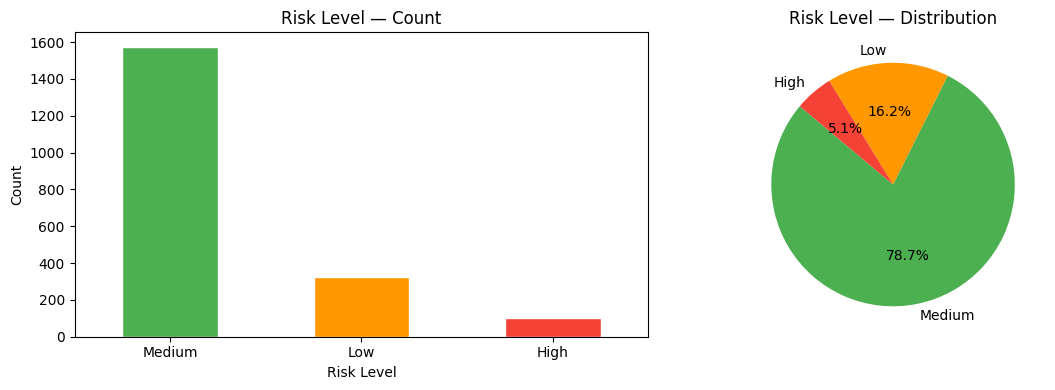

Risk_Level
Medium    1574
Low        324
High       102
Name: count, dtype: int64


In [6]:
# ─────────────────────────────────────────────────────────────────────────────
# Visualise the class distribution of the target variable Risk_Level.
# Understanding class imbalance is critical — it motivates the use of
# SMOTE and class-weighted models later in the pipeline.
# ─────────────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
vc = df['Risk_Level'].value_counts()
vc.plot(kind='bar', ax=axes[0], color=['#4CAF50','#FF9800','#F44336'], edgecolor='white')
axes[0].set_title('Risk Level — Count')
axes[0].set_xlabel('Risk Level')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

# Pie chart
vc.plot(kind='pie', ax=axes[1], autopct='%1.1f%%',
        colors=['#4CAF50','#FF9800','#F44336'], startangle=140)
axes[1].set_ylabel('')
axes[1].set_title('Risk Level — Distribution')

plt.tight_layout()
plt.savefig('eda_target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(vc)

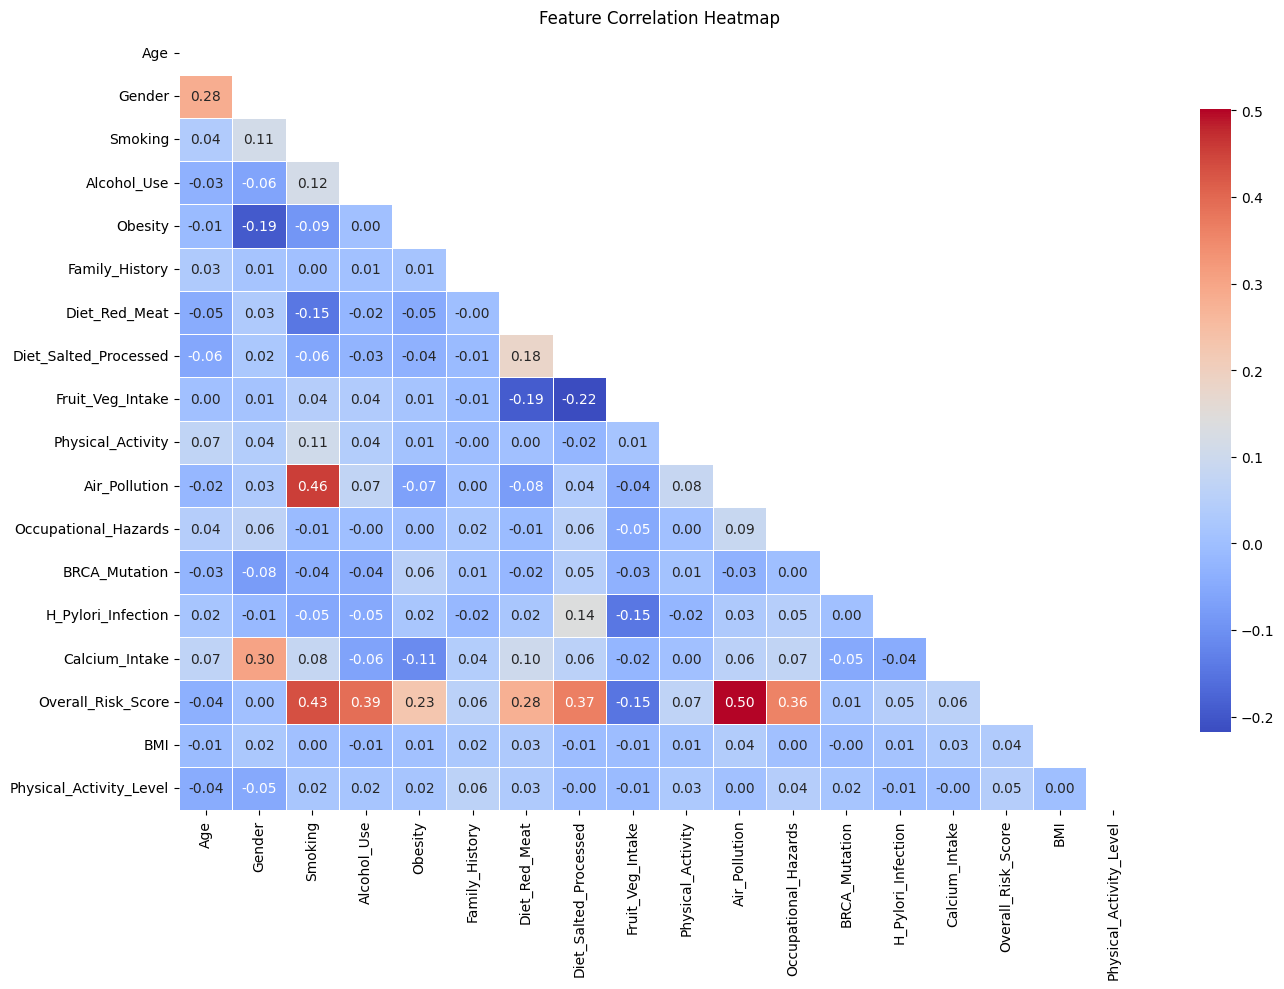

In [7]:
# ─────────────────────────────────────────────────────────────────────────────
# Correlation heatmap of numeric features.
# High correlations can indicate redundant features or data leakage
# (e.g. Overall_Risk_Score is highly correlated with the target and
#  will be dropped before modelling).
# ─────────────────────────────────────────────────────────────────────────────
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

plt.figure(figsize=(14, 10))
corr = df[numeric_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))   # show only lower triangle
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.savefig('eda_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

---
## ⚙️ Section 4 — Feature Engineering & Train/Test Split

In [8]:
# ─────────────────────────────────────────────────────────────────────────────
# Feature selection rationale:
#   Patient_ID   → identifier, not a predictor
#   Cancer_Type  → outcome label / grouping variable, not an input feature
#   Overall_Risk_Score → composite score derived from the target; would cause
#                        data leakage if included in features
#
# We keep all remaining clinical & lifestyle columns as features (X) and
# encode the ordinal target Risk_Level (Low=0, Medium=1, High=2 via LabelEncoder).
# ─────────────────────────────────────────────────────────────────────────────
DROP_COLS = ['Risk_Level', 'Patient_ID', 'Cancer_Type', 'Overall_Risk_Score']

X = df.drop(columns=DROP_COLS)
y = df['Risk_Level']   # keep as string labels for now; encode per-model below

FEATURE_NAMES = X.columns.tolist()
print(f'Features ({len(FEATURE_NAMES)}): {FEATURE_NAMES}')
print(f'Target classes: {sorted(y.unique())}')

Features (17): ['Age', 'Gender', 'Smoking', 'Alcohol_Use', 'Obesity', 'Family_History', 'Diet_Red_Meat', 'Diet_Salted_Processed', 'Fruit_Veg_Intake', 'Physical_Activity', 'Air_Pollution', 'Occupational_Hazards', 'BRCA_Mutation', 'H_Pylori_Infection', 'Calcium_Intake', 'BMI', 'Physical_Activity_Level']
Target classes: ['High', 'Low', 'Medium']


In [9]:
# ─────────────────────────────────────────────────────────────────────────────
# Stratified 80/20 split — stratify=y ensures each split maintains the
# same class proportions as the full dataset, which is crucial for
# imbalanced multi-class problems.
# random_state=42 for full reproducibility.
# ─────────────────────────────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train set : {X_train.shape}  |  Test set: {X_test.shape}')
print('\nTrain class distribution:')
print(y_train.value_counts())
print('\nTest class distribution:')
print(y_test.value_counts())

Train set : (1600, 17)  |  Test set: (400, 17)

Train class distribution:
Risk_Level
Medium    1259
Low        259
High        82
Name: count, dtype: int64

Test class distribution:
Risk_Level
Medium    315
Low        65
High       20
Name: count, dtype: int64


---
## 🌲 Section 5 — Baseline Models (with StandardScaler)

In [10]:
# ─────────────────────────────────────────────────────────────────────────────
# StandardScaler normalises features to zero mean & unit variance.
# Fit ONLY on training data to prevent data leakage;
# apply the same transform to the test set.
# NOTE: Scaler is applied only for the baseline section.
#       XGBoost (tree-based) does not require scaling.
# ─────────────────────────────────────────────────────────────────────────────
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit + transform train
X_test_scaled  = scaler.transform(X_test)        # transform test only

# Encode labels for baseline models
le_base = LabelEncoder()
y_train_enc_base = le_base.fit_transform(y_train)
y_test_enc_base  = le_base.transform(y_test)

print('Scaler fitted. Encoded classes:', le_base.classes_)

Scaler fitted. Encoded classes: ['High' 'Low' 'Medium']


In [11]:
# ─────────────────────────────────────────────────────────────────────────────
# Baseline Random Forest — default 100 trees.
# Serves as a reference to compare against tuned models.
# ─────────────────────────────────────────────────────────────────────────────
rf_baseline = RandomForestClassifier(n_estimators=100, random_state=42)
rf_baseline.fit(X_train_scaled, y_train_enc_base)

y_pred_rf_base = rf_baseline.predict(X_test_scaled)

print('=' * 55)
print('  BASELINE — Random Forest (100 trees, scaled features)')
print('=' * 55)
print(classification_report(y_test_enc_base, y_pred_rf_base,
                             target_names=le_base.classes_))
print('Confusion Matrix:')
print(confusion_matrix(y_test_enc_base, y_pred_rf_base))

  BASELINE — Random Forest (100 trees, scaled features)
              precision    recall  f1-score   support

        High       1.00      0.05      0.10        20
         Low       0.85      0.34      0.48        65
      Medium       0.83      0.99      0.90       315

    accuracy                           0.83       400
   macro avg       0.89      0.46      0.49       400
weighted avg       0.84      0.83      0.80       400

Confusion Matrix:
[[  1   0  19]
 [  0  22  43]
 [  0   4 311]]


In [12]:
# ─────────────────────────────────────────────────────────────────────────────
# Baseline Logistic Regression — linear decision boundaries.
# Typically weaker on non-linear medical data but useful as a sanity check.
# Requires scaled features (done above).
# ─────────────────────────────────────────────────────────────────────────────
lr_baseline = LogisticRegression(random_state=42, max_iter=1000)
lr_baseline.fit(X_train_scaled, y_train_enc_base)

y_pred_lr_base = lr_baseline.predict(X_test_scaled)

print('=' * 55)
print('  BASELINE — Logistic Regression')
print('=' * 55)
print(classification_report(y_test_enc_base, y_pred_lr_base,
                             target_names=le_base.classes_))
print('Confusion Matrix:')
print(confusion_matrix(y_test_enc_base, y_pred_lr_base))

  BASELINE — Logistic Regression
              precision    recall  f1-score   support

        High       0.50      0.20      0.29        20
         Low       0.85      0.78      0.82        65
      Medium       0.91      0.96      0.93       315

    accuracy                           0.89       400
   macro avg       0.75      0.65      0.68       400
weighted avg       0.88      0.89      0.88       400

Confusion Matrix:
[[  4   0  16]
 [  0  51  14]
 [  4   9 302]]


---
## ⚖️ Section 6 — SMOTE + Random Forest (Imbalance Handling)

In [13]:
# ─────────────────────────────────────────────────────────────────────────────
# SMOTE (Synthetic Minority Over-Sampling Technique) synthesises new samples
# for under-represented classes by interpolating between existing minority-
# class neighbours. Applied ONLY to the training set to prevent leakage.
#
# NOTE: X_train / y_train are raw (unscaled) DataFrames here — RandomForest
#       is scale-invariant, so no scaler is needed.
# ─────────────────────────────────────────────────────────────────────────────
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print('Class distribution AFTER SMOTE resampling:')
print(pd.Series(y_train_res).value_counts())
print(f'\nResampled training size: {X_train_res.shape}')

Class distribution AFTER SMOTE resampling:
Risk_Level
Medium    1259
Low       1259
High      1259
Name: count, dtype: int64

Resampled training size: (3777, 17)


In [14]:
# ─────────────────────────────────────────────────────────────────────────────
# Random Forest trained on SMOTE-resampled data.
# Compare results with baseline RF to see the effect of balancing.
# ─────────────────────────────────────────────────────────────────────────────
rf_smote = RandomForestClassifier(n_estimators=100, random_state=42)
rf_smote.fit(X_train_res, y_train_res)

y_pred_rf_smote = rf_smote.predict(X_test)

print('=' * 55)
print('  SMOTE — Random Forest (100 trees)')
print('=' * 55)
print(classification_report(y_test, y_pred_rf_smote))
print('Confusion Matrix:')
print(confusion_matrix(y_test, y_pred_rf_smote))

  SMOTE — Random Forest (100 trees)
              precision    recall  f1-score   support

        High       0.41      0.35      0.38        20
         Low       0.73      0.58      0.65        65
      Medium       0.88      0.92      0.90       315

    accuracy                           0.84       400
   macro avg       0.67      0.62      0.64       400
weighted avg       0.83      0.84      0.83       400

Confusion Matrix:
[[  7   0  13]
 [  0  38  27]
 [ 10  14 291]]


---
## 🔬 Section 7 — Optuna Hyperparameter Tuning: Random Forest

In [15]:
# ─────────────────────────────────────────────────────────────────────────────
# Optuna uses the TPE (Tree-structured Parzen Estimator) sampler — a
# Bayesian optimisation strategy that models P(params | good trial) to
# propose better hyperparameter candidates over successive trials.
#
# Objective: maximise macro-F1 via 3-fold stratified cross-validation.
# Macro-F1 penalises poor performance on any single class equally,
# making it appropriate for imbalanced multi-class tasks.
#
# SMOTE is applied INSIDE each CV fold to prevent leakage.
# ─────────────────────────────────────────────────────────────────────────────

def rf_objective(trial):
    """Optuna objective: returns mean macro-F1 across 3 CV folds."""
    params = {
        'n_estimators'     : trial.suggest_int('n_estimators', 100, 400),
        'max_depth'        : trial.suggest_int('max_depth', 6, 20),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 8),
        'min_samples_leaf' : trial.suggest_int('min_samples_leaf', 1, 6),
        'max_features'     : trial.suggest_categorical('max_features', ['sqrt', 'log2']),
        'bootstrap'        : trial.suggest_categorical('bootstrap', [True, False]),
        'criterion'        : trial.suggest_categorical('criterion', ['gini', 'entropy']),
        'random_state'     : 42,
        'n_jobs'           : 1   # avoid nested parallelism inside CV
    }

    sm   = SMOTE(random_state=42)
    rf   = RandomForestClassifier(**params)
    pipe = ImbPipeline([('smote', sm), ('rf', rf)])

    macro_f1_scorer = make_scorer(f1_score, average='macro')
    cv     = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    scores = cross_val_score(pipe, X_train, y_train, cv=cv,
                             scoring=macro_f1_scorer, n_jobs=1)
    return float(np.mean(scores))

print('RF Optuna objective defined ✅')

RF Optuna objective defined ✅


In [17]:
# ─────────────────────────────────────────────────────────────────────────────
# FIX: NaN trials were caused by macro-F1 returning NaN when a CV fold
# had no predictions for a minority class.
# Changes made:
#   1. Added zero_division=0 to f1_score — returns 0 instead of NaN
#   2. Filter out NaN scores before averaging (np.nanmean)
#   3. Return 0.0 if all fold scores are NaN (trial will be low-ranked, not failed)
#   4. Wrapped objective in try/except to catch any remaining edge cases
# ─────────────────────────────────────────────────────────────────────────────

def rf_objective(trial):
    """Optuna objective: returns mean macro-F1 across 3 CV folds."""
    params = {
        'n_estimators'     : trial.suggest_int('n_estimators', 100, 400),
        'max_depth'        : trial.suggest_int('max_depth', 6, 20),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 8),
        'min_samples_leaf' : trial.suggest_int('min_samples_leaf', 1, 6),
        'max_features'     : trial.suggest_categorical('max_features', ['sqrt', 'log2']),
        'bootstrap'        : trial.suggest_categorical('bootstrap', [True, False]),
        'criterion'        : trial.suggest_categorical('criterion', ['gini', 'entropy']),
        'random_state'     : 42,
        'n_jobs'           : 1
    }

    try:
        sm   = SMOTE(random_state=42)
        rf   = RandomForestClassifier(**params)
        pipe = ImbPipeline([('smote', sm), ('rf', rf)])

        cv     = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
        scores = []

        for tr_idx, val_idx in cv.split(X_train, y_train):
            X_t, X_v = X_train.iloc[tr_idx], X_train.iloc[val_idx]
            y_t, y_v = y_train.iloc[tr_idx], y_train.iloc[val_idx]
            pipe.fit(X_t, y_t)
            y_p   = pipe.predict(X_v)
            score = f1_score(y_v, y_p, average='macro', zero_division=0)  # FIX 1
            if not np.isnan(score):                                         # FIX 2
                scores.append(score)

        return float(np.mean(scores)) if scores else 0.0                   # FIX 3

    except Exception as e:                                                  # FIX 4
        print(f"Trial error: {e}")
        return 0.0


# ─────────────────────────────────────────────────────────────────────────────
# Re-run the study with the fixed objective.
# ─────────────────────────────────────────────────────────────────────────────
rf_study = optuna.create_study(
    direction='maximize',
    sampler=TPESampler(seed=42),
    study_name='rf_macro_f1'
)
rf_study.optimize(rf_objective, n_trials=30, show_progress_bar=True)

print(f'\n✅ Best CV macro-F1 (RF): {rf_study.best_value:.4f}')
print('Best params:')
for k, v in rf_study.best_params.items():
    print(f'  {k}: {v}')

  0%|          | 0/30 [00:00<?, ?it/s]


✅ Best CV macro-F1 (RF): 0.6955
Best params:
  n_estimators: 119
  max_depth: 14
  min_samples_split: 5
  min_samples_leaf: 5
  max_features: sqrt
  bootstrap: True
  criterion: entropy


In [18]:
# ─────────────────────────────────────────────────────────────────────────────
# Train the final RF pipeline using best Optuna params on the full training
# set (SMOTE applied inside the pipeline), then evaluate on the held-out test.
# ─────────────────────────────────────────────────────────────────────────────
best_rf_params = rf_study.best_params.copy()
best_rf_params.update({'random_state': 42, 'n_jobs': -1})

rf_tuned      = RandomForestClassifier(**best_rf_params)
rf_pipe_final = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('rf',    rf_tuned)
])
rf_pipe_final.fit(X_train, y_train)

y_pred_rf_tuned = rf_pipe_final.predict(X_test)

print('=' * 55)
print('  OPTUNA-TUNED — Random Forest (SMOTE pipeline)')
print('=' * 55)
print(classification_report(y_test, y_pred_rf_tuned))
print('Confusion Matrix:')
print(confusion_matrix(y_test, y_pred_rf_tuned))

  OPTUNA-TUNED — Random Forest (SMOTE pipeline)
              precision    recall  f1-score   support

        High       0.35      0.45      0.39        20
         Low       0.71      0.63      0.67        65
      Medium       0.89      0.89      0.89       315

    accuracy                           0.83       400
   macro avg       0.65      0.66      0.65       400
weighted avg       0.83      0.83      0.83       400

Confusion Matrix:
[[  9   0  11]
 [  0  41  24]
 [ 17  17 281]]


---
## ⚡ Section 8 — Baseline XGBoost (SMOTE Pipeline)

In [19]:
# ─────────────────────────────────────────────────────────────────────────────
# XGBoost requires integer-encoded labels (0, 1, 2 …).
# A LabelEncoder is fitted on y_train to produce consistent integer mappings.
# SMOTE is applied inside the pipeline on each CV fold to avoid leakage.
# ─────────────────────────────────────────────────────────────────────────────
le = LabelEncoder()
le.fit(y_train)                          # fit only on train labels
y_train_enc = le.transform(y_train)
y_test_enc  = le.transform(y_test)

print('Label encoding:', dict(zip(le.classes_, le.transform(le.classes_))))

# Baseline XGBoost inside SMOTE pipeline
xgb_base = XGBClassifier(
    eval_metric='mlogloss',
    random_state=42,
    n_jobs=-1
)
xgb_base_pipe = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('xgb',   xgb_base)
])
xgb_base_pipe.fit(X_train, y_train_enc)

y_pred_xgb_base_enc = xgb_base_pipe.predict(X_test)
y_pred_xgb_base     = le.inverse_transform(y_pred_xgb_base_enc)

print('=' * 55)
print('  BASELINE — XGBoost (SMOTE pipeline)')
print('=' * 55)
print(classification_report(y_test, y_pred_xgb_base))
print('Confusion Matrix:')
print(confusion_matrix(y_test, y_pred_xgb_base, labels=le.classes_))

Label encoding: {'High': np.int64(0), 'Low': np.int64(1), 'Medium': np.int64(2)}
  BASELINE — XGBoost (SMOTE pipeline)
              precision    recall  f1-score   support

        High       0.39      0.45      0.42        20
         Low       0.79      0.68      0.73        65
      Medium       0.90      0.92      0.91       315

    accuracy                           0.85       400
   macro avg       0.69      0.68      0.68       400
weighted avg       0.86      0.85      0.85       400

Confusion Matrix:
[[  9   0  11]
 [  0  44  21]
 [ 14  12 289]]


---
## 🎯 Section 9 — Optuna XGBoost: Maximise High-Class Recall

In [20]:
# ─────────────────────────────────────────────────────────────────────────────
# Clinical motivation: false negatives for 'High' risk patients are very
# costly — a missed high-risk case can have severe health consequences.
# Therefore this study explicitly maximises recall for the 'High' class.
#
# SMOTE is applied inside each CV fold via ImbPipeline.
# ─────────────────────────────────────────────────────────────────────────────
TARGET_LABEL  = 'High'
target_idx    = int(np.where(le.classes_ == TARGET_LABEL)[0])   # encoded integer for 'High'

def xgb_recall_objective(trial):
    """Optuna objective: returns mean recall for the 'High' class across 3 CV folds."""
    params = {
        'n_estimators'    : trial.suggest_int('n_estimators', 50, 400),
        'max_depth'       : trial.suggest_int('max_depth', 3, 12),
        'learning_rate'   : trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample'       : trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.4, 1.0),
        'gamma'           : trial.suggest_float('gamma', 0.0, 5.0),
        'reg_alpha'       : trial.suggest_float('reg_alpha', 0.0, 5.0),
        'reg_lambda'      : trial.suggest_float('reg_lambda', 0.0, 5.0),
        'eval_metric'     : 'mlogloss',
        'random_state'    : 42,
    }

    xgb  = XGBClassifier(**params, n_jobs=1)
    pipe = ImbPipeline([('smote', SMOTE(random_state=42)), ('xgb', xgb)])

    cv      = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    recalls = []

    for tr_idx, val_idx in cv.split(X_train, y_train_enc):
        X_t, X_v = X_train.iloc[tr_idx], X_train.iloc[val_idx]
        y_t, y_v = y_train_enc[tr_idx],  y_train_enc[val_idx]
        pipe.fit(X_t, y_t)
        y_p  = pipe.predict(X_v)
        # per-class recall; pick the index corresponding to 'High'
        recs = recall_score(y_v, y_p, labels=list(range(len(le.classes_))),
                            average=None, zero_division=0)
        recalls.append(recs[target_idx])

    return float(np.mean(recalls))

print('XGB High-recall objective defined ✅')

XGB High-recall objective defined ✅


In [21]:
# Run the High-recall Optuna study (40 trials)
xgb_recall_study = optuna.create_study(
    direction='maximize',
    sampler=TPESampler(seed=42),
    study_name='xgb_high_recall'
)
xgb_recall_study.optimize(xgb_recall_objective, n_trials=40, show_progress_bar=True)

print(f'\n✅ Best CV High-recall (XGB): {xgb_recall_study.best_value:.4f}')
print('Best params:')
for k, v in xgb_recall_study.best_params.items():
    print(f'  {k}: {v}')

  0%|          | 0/40 [00:00<?, ?it/s]


✅ Best CV High-recall (XGB): 0.7218
Best params:
  n_estimators: 105
  max_depth: 3
  learning_rate: 0.014843806162322944
  subsample: 0.7730982444721965
  colsample_bytree: 0.8509237341976973
  gamma: 4.134336554829186
  reg_alpha: 4.453508368364819
  reg_lambda: 2.616923339470738


In [22]:
# ─────────────────────────────────────────────────────────────────────────────
# Train final High-recall XGB model on full training set and evaluate.
# ─────────────────────────────────────────────────────────────────────────────
best_recall_params = xgb_recall_study.best_params.copy()
best_recall_params.update({'eval_metric': 'mlogloss', 'random_state': 42})

xgb_recall_final = XGBClassifier(**best_recall_params, n_jobs=-1)
xgb_recall_pipe  = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('xgb',   xgb_recall_final)
])
xgb_recall_pipe.fit(X_train, y_train_enc)

y_pred_recall_enc = xgb_recall_pipe.predict(X_test)
y_pred_recall     = le.inverse_transform(y_pred_recall_enc)

print('=' * 55)
print('  OPTUNA XGB — Max High-Recall')
print('=' * 55)
print(classification_report(y_test, y_pred_recall, labels=le.classes_))
print('Confusion Matrix:')
print(confusion_matrix(y_test, y_pred_recall, labels=le.classes_))

  OPTUNA XGB — Max High-Recall
              precision    recall  f1-score   support

        High       0.15      0.65      0.25        20
         Low       0.44      0.71      0.54        65
      Medium       0.88      0.59      0.71       315

    accuracy                           0.61       400
   macro avg       0.49      0.65      0.50       400
weighted avg       0.77      0.61      0.66       400

Confusion Matrix:
[[ 13   0   7]
 [  1  46  18]
 [ 70  59 186]]


---
## 🏆 Section 10 — WINNER: Optuna Class-Weighted XGBoost (Macro-F1)

In [23]:
# ─────────────────────────────────────────────────────────────────────────────
# Class-Weighted XGBoost Strategy:
#   Instead of SMOTE (which synthetically augments data), we assign higher
#   sample weights to minority-class examples during model fitting.
#   Weight for class c = max(class_count) / count(c)
#   This makes the model penalise misclassifications on rare classes more.
#
# Objective: macro-F1 — treats all three risk classes equally.
# Weights are re-computed from each CV fold's training split to avoid leakage.
# ─────────────────────────────────────────────────────────────────────────────

def compute_sample_weights(y_enc):
    """Return per-sample weights inversely proportional to class frequency."""
    classes, counts      = np.unique(y_enc, return_counts=True)
    class_weight_map     = {cls: float(max(counts) / cnt) for cls, cnt in zip(classes, counts)}
    return np.array([class_weight_map[yi] for yi in y_enc])


def cw_xgb_objective(trial):
    """Optuna objective: returns mean macro-F1 across 3 CV folds (class-weighted XGB)."""
    params = {
        'n_estimators'    : trial.suggest_int('n_estimators', 50, 400),
        'max_depth'       : trial.suggest_int('max_depth', 2, 12),
        'learning_rate'   : trial.suggest_float('learning_rate', 1e-3, 0.3, log=True),
        'subsample'       : trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.4, 1.0),
        'gamma'           : trial.suggest_float('gamma', 0.0, 5.0),
        'reg_alpha'       : trial.suggest_float('reg_alpha', 0.0, 5.0),
        'reg_lambda'      : trial.suggest_float('reg_lambda', 0.0, 5.0),
        'eval_metric'     : 'mlogloss',
    }

    cv     = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    scores = []

    for tr_idx, val_idx in cv.split(X_train, y_train_enc):
        X_t, X_v = X_train.iloc[tr_idx], X_train.iloc[val_idx]
        y_t, y_v = y_train_enc[tr_idx],  y_train_enc[val_idx]

        sw    = compute_sample_weights(y_t)   # fold-level weights — no leakage
        model = XGBClassifier(**params, n_jobs=1, random_state=42)
        model.fit(X_t, y_t, sample_weight=sw, verbose=False)

        y_p = model.predict(X_v)
        scores.append(f1_score(y_v, y_p, average='macro'))

    return float(np.mean(scores))

print('Class-weighted XGB objective defined ✅')

Class-weighted XGB objective defined ✅


In [24]:
# ─────────────────────────────────────────────────────────────────────────────
# Run the class-weighted Optuna study (40 trials).
# ─────────────────────────────────────────────────────────────────────────────
cw_xgb_study = optuna.create_study(
    direction='maximize',
    sampler=TPESampler(seed=42),
    study_name='xgb_class_weighted_macroF1'
)
cw_xgb_study.optimize(cw_xgb_objective, n_trials=40, show_progress_bar=True)

print(f'\n✅ Best CV macro-F1 (Class-Weighted XGB): {cw_xgb_study.best_value:.4f}')
print('Best params:')
for k, v in cw_xgb_study.best_params.items():
    print(f'  {k}: {v}')

  0%|          | 0/40 [00:00<?, ?it/s]


✅ Best CV macro-F1 (Class-Weighted XGB): 0.7167
Best params:
  n_estimators: 304
  max_depth: 11
  learning_rate: 0.08007286360933288
  subsample: 0.743074596045066
  colsample_bytree: 0.46548655368448905
  gamma: 0.7978753628088727
  reg_alpha: 1.9672780502868439
  reg_lambda: 2.0390163529054015


In [25]:
# ─────────────────────────────────────────────────────────────────────────────
# Train the final class-weighted XGBoost on the full training set.
# Sample weights are derived from the full training distribution.
# ─────────────────────────────────────────────────────────────────────────────
best_cw = cw_xgb_study.best_params.copy()
best_cw.update({'eval_metric': 'mlogloss', 'random_state': 42})

final_sample_weights = compute_sample_weights(y_train_enc)

final_xgb = XGBClassifier(**best_cw, n_jobs=-1)
final_xgb.fit(
    X_train, y_train_enc,
    sample_weight=final_sample_weights,
    verbose=False
)

# Predict on held-out test set
y_pred_final_enc = final_xgb.predict(X_test)
y_pred_final     = le.inverse_transform(y_pred_final_enc)

print('=' * 60)
print('  🏆  FINAL MODEL — Optuna Class-Weighted XGBoost')
print('=' * 60)
print(classification_report(y_test, y_pred_final, labels=le.classes_))
print('Confusion Matrix (rows=true, cols=predicted):')
cm = confusion_matrix(y_test, y_pred_final, labels=le.classes_)
print(cm)

  🏆  FINAL MODEL — Optuna Class-Weighted XGBoost
              precision    recall  f1-score   support

        High       0.50      0.45      0.47        20
         Low       0.76      0.78      0.77        65
      Medium       0.92      0.92      0.92       315

    accuracy                           0.88       400
   macro avg       0.73      0.72      0.72       400
weighted avg       0.87      0.88      0.87       400

Confusion Matrix (rows=true, cols=predicted):
[[  9   0  11]
 [  0  51  14]
 [  9  16 290]]


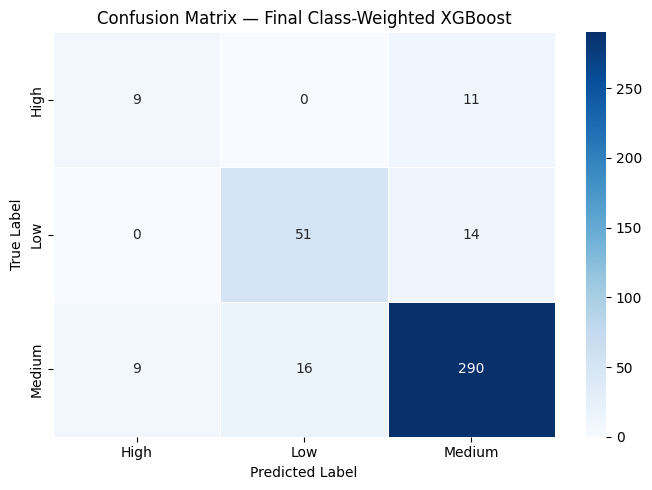

In [26]:
# ─────────────────────────────────────────────────────────────────────────────
# Visualise the final model's confusion matrix as a colour-coded heatmap.
# Each cell shows the count of predictions; diagonal = correct predictions.
# ─────────────────────────────────────────────────────────────────────────────
plt.figure(figsize=(7, 5))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=le.classes_, yticklabels=le.classes_,
    linewidths=0.5
)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix — Final Class-Weighted XGBoost')
plt.tight_layout()
plt.savefig('confusion_matrix_final.png', dpi=150, bbox_inches='tight')
plt.show()

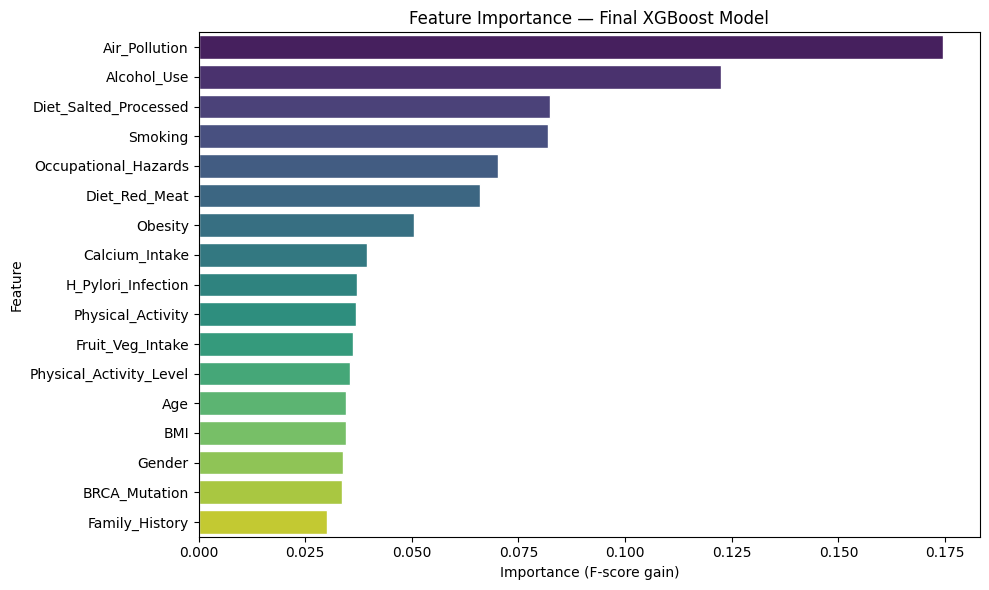

                    feature  importance
0             Air_Pollution    0.174456
1               Alcohol_Use    0.122359
2     Diet_Salted_Processed    0.082338
3                   Smoking    0.081867
4      Occupational_Hazards    0.070268
5             Diet_Red_Meat    0.065947
6                   Obesity    0.050581
7            Calcium_Intake    0.039523
8        H_Pylori_Infection    0.037236
9         Physical_Activity    0.036943
10         Fruit_Veg_Intake    0.036210
11  Physical_Activity_Level    0.035447
12                      Age    0.034567
13                      BMI    0.034559
14                   Gender    0.033893
15            BRCA_Mutation    0.033648
16           Family_History    0.030161


In [27]:
# ─────────────────────────────────────────────────────────────────────────────
# Feature importance from the final XGBoost model.
# 'gain' measures the average improvement in loss when a feature is used
# to split — generally more informative than count-based importance.
# ─────────────────────────────────────────────────────────────────────────────
importance_df = (
    pd.DataFrame({
        'feature'   : FEATURE_NAMES,
        'importance': final_xgb.feature_importances_
    })
    .sort_values('importance', ascending=False)
    .reset_index(drop=True)
)

plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df, x='importance', y='feature',
            palette='viridis', edgecolor='white')
plt.title('Feature Importance — Final XGBoost Model')
plt.xlabel('Importance (F-score gain)')
plt.ylabel('Feature')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print(importance_df)

---
## 📊 Section 11 — MLflow Experiment Tracking

In [28]:
# ─────────────────────────────────────────────────────────────────────────────
# Configure MLflow tracking URI (already set via env var in Section 1).
# All runs are grouped under the experiment 'Cancer_Risk_Prediction'.
# ─────────────────────────────────────────────────────────────────────────────
import mlflow
import mlflow.xgboost

mlflow.set_tracking_uri(os.environ['MLFLOW_TRACKING_URI'])
mlflow.set_experiment('Cancer_Risk_Prediction')

print(f'MLflow tracking URI: {mlflow.get_tracking_uri()}')

2026/03/22 07:06:54 INFO mlflow.tracking.fluent: Experiment with name 'Cancer_Risk_Prediction' does not exist. Creating a new experiment.


MLflow tracking URI: https://dagshub.com/prithusarkar90/networksecurity.mlflow


In [29]:
# ─────────────────────────────────────────────────────────────────────────────
# Log all four models to MLflow with their key metrics.
# Each model gets its own run so results are easy to compare in the UI.
# The final XGBoost model is also logged as a serialised artifact.
# ─────────────────────────────────────────────────────────────────────────────

def log_model_run(run_name, model, y_true, y_pred, le_obj, extra_params=None):
    """Helper: open an MLflow run, compute metrics, log, and close."""
    with mlflow.start_run(run_name=run_name):
        # Metrics
        macro_f1  = f1_score(y_true, y_pred, average='macro')
        high_rec  = recall_score(y_true, y_pred, labels=['High'],
                                 average='macro', zero_division=0)
        mlflow.log_metric('macro_f1',    macro_f1)
        mlflow.log_metric('high_recall', high_rec)

        # Hyperparameters
        if extra_params:
            mlflow.log_params(extra_params)

        # Tags for easy filtering
        mlflow.set_tag('model_type', type(model).__name__)

        print(f'[{run_name}]  macro-F1={macro_f1:.4f}  High-recall={high_rec:.4f}')


# ── Baseline RF ───────────────────────────────────────────────────────────────
log_model_run(
    'baseline_random_forest',
    rf_baseline,
    y_test, le_base.inverse_transform(y_pred_rf_base),
    le_base,
    extra_params={'n_estimators': 100, 'scaler': 'StandardScaler'}
)

# ── Baseline Logistic Regression ─────────────────────────────────────────────
log_model_run(
    'baseline_logistic_regression',
    lr_baseline,
    y_test, le_base.inverse_transform(y_pred_lr_base),
    le_base,
    extra_params={'max_iter': 1000, 'scaler': 'StandardScaler'}
)

# ── SMOTE RF ──────────────────────────────────────────────────────────────────
log_model_run(
    'smote_random_forest',
    rf_smote,
    y_test, y_pred_rf_smote,
    le,
    extra_params={'n_estimators': 100, 'balancing': 'SMOTE'}
)

# ── Optuna RF ─────────────────────────────────────────────────────────────────
log_model_run(
    'optuna_random_forest',
    rf_pipe_final,
    y_test, y_pred_rf_tuned,
    le,
    extra_params={'optuna_trials': 30, 'balancing': 'SMOTE_pipeline', **rf_study.best_params}
)

# ── Optuna XGB High-Recall ────────────────────────────────────────────────────
log_model_run(
    'optuna_xgb_high_recall',
    xgb_recall_pipe,
    y_test, y_pred_recall,
    le,
    extra_params={'optuna_trials': 40, 'objective': 'high_recall', **xgb_recall_study.best_params}
)

# ── Final Class-Weighted XGB (log model artifact too) ─────────────────────────
with mlflow.start_run(run_name='FINAL_class_weighted_xgb'):
    macro_f1  = f1_score(y_test, y_pred_final, average='macro')
    high_rec  = recall_score(y_test, y_pred_final, labels=['High'],
                             average='macro', zero_division=0)
    mlflow.log_metric('macro_f1',    macro_f1)
    mlflow.log_metric('high_recall', high_rec)
    mlflow.log_params({'optuna_trials': 40, 'balancing': 'class_weights', **best_cw})
    mlflow.set_tag('model_type', 'XGBClassifier')
    mlflow.set_tag('winner', 'true')
    # Log the trained XGBoost model as an MLflow artifact
    mlflow.xgboost.log_model(final_xgb, artifact_path='xgb_model')
    # Log EDA and evaluation plots
    for png in ['eda_target_distribution.png', 'eda_correlation_heatmap.png',
                'confusion_matrix_final.png', 'feature_importance.png']:
        if os.path.exists(png):
            mlflow.log_artifact(png, artifact_path='plots')
    print(f'[FINAL_class_weighted_xgb]  macro-F1={macro_f1:.4f}  High-recall={high_rec:.4f}')

print('\n✅ All runs logged to MLflow.')

[baseline_random_forest]  macro-F1=0.4943  High-recall=0.0500
🏃 View run baseline_random_forest at: https://dagshub.com/prithusarkar90/networksecurity.mlflow/#/experiments/5/runs/2d6710c2718443529e349f2a1cc1bc03
🧪 View experiment at: https://dagshub.com/prithusarkar90/networksecurity.mlflow/#/experiments/5
[baseline_logistic_regression]  macro-F1=0.6784  High-recall=0.2000
🏃 View run baseline_logistic_regression at: https://dagshub.com/prithusarkar90/networksecurity.mlflow/#/experiments/5/runs/9f58885b2322469faa26598420a1ac79
🧪 View experiment at: https://dagshub.com/prithusarkar90/networksecurity.mlflow/#/experiments/5
[smote_random_forest]  macro-F1=0.6430  High-recall=0.3500
🏃 View run smote_random_forest at: https://dagshub.com/prithusarkar90/networksecurity.mlflow/#/experiments/5/runs/a368ab5ad67c430abef81be6aafe1cdd
🧪 View experiment at: https://dagshub.com/prithusarkar90/networksecurity.mlflow/#/experiments/5
[optuna_random_forest]  macro-F1=0.6495  High-recall=0.4500
🏃 View run

2026/03/22 07:07:38 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


[FINAL_class_weighted_xgb]  macro-F1=0.7223  High-recall=0.4500
🏃 View run FINAL_class_weighted_xgb at: https://dagshub.com/prithusarkar90/networksecurity.mlflow/#/experiments/5/runs/bebbd3ba40ed4de19bca744c7a85104b
🧪 View experiment at: https://dagshub.com/prithusarkar90/networksecurity.mlflow/#/experiments/5

✅ All runs logged to MLflow.


---
## 💾 Section 12 — Save Model Artifacts

In [30]:
# ─────────────────────────────────────────────────────────────────────────────
# Serialise all artifacts needed for inference in the Streamlit app:
#   final_xgb_class_weighted.pkl  — the trained XGBoost model
#   label_encoder.pkl             — LabelEncoder fitted on y_train
#   feature_names.pkl             — ordered list of feature column names
#
# joblib is preferred over pickle for large NumPy arrays (faster, smaller).
# ─────────────────────────────────────────────────────────────────────────────
ARTIFACTS_DIR = 'artifacts'
os.makedirs(ARTIFACTS_DIR, exist_ok=True)

MODEL_PATH    = os.path.join(ARTIFACTS_DIR, 'final_xgb_class_weighted.pkl')
LE_PATH       = os.path.join(ARTIFACTS_DIR, 'label_encoder.pkl')
FEATURES_PATH = os.path.join(ARTIFACTS_DIR, 'feature_names.pkl')

joblib.dump(final_xgb,    MODEL_PATH)
joblib.dump(le,           LE_PATH)
joblib.dump(FEATURE_NAMES, FEATURES_PATH)

print(f'✅ Model saved      → {MODEL_PATH}')
print(f'✅ LabelEncoder     → {LE_PATH}')
print(f'✅ Feature names    → {FEATURES_PATH}')

✅ Model saved      → artifacts/final_xgb_class_weighted.pkl
✅ LabelEncoder     → artifacts/label_encoder.pkl
✅ Feature names    → artifacts/feature_names.pkl


In [31]:
# ─────────────────────────────────────────────────────────────────────────────
# Quick sanity-check: reload artifacts and run a single inference to confirm
# the saved model produces the same predictions as the in-memory model.
# ─────────────────────────────────────────────────────────────────────────────
loaded_model    = joblib.load(MODEL_PATH)
loaded_le       = joblib.load(LE_PATH)
loaded_features = joblib.load(FEATURES_PATH)

# Predict first test row
sample      = X_test.iloc[[0]][loaded_features]
pred_enc    = loaded_model.predict(sample)[0]
pred_label  = loaded_le.inverse_transform([pred_enc])[0]
pred_proba  = loaded_model.predict_proba(sample)[0]

print('Sanity check — sample prediction:')
print(f'  True label    : {y_test.iloc[0]}')
print(f'  Predicted     : {pred_label}')
print(f'  Class probs   : {dict(zip(loaded_le.classes_, pred_proba.round(3)))}')
print('✅ Artifact reload verified.')

Sanity check — sample prediction:
  True label    : Medium
  Predicted     : Medium
  Class probs   : {'High': np.float32(0.075), 'Low': np.float32(0.024), 'Medium': np.float32(0.9)}
✅ Artifact reload verified.


---
## 📦 Section 13 — Package All Outputs as ZIP

In [32]:
# ─────────────────────────────────────────────────────────────────────────────
# Collect all output files (models, plots, report) into a single ZIP archive
# for easy download from the Colab environment.
# ─────────────────────────────────────────────────────────────────────────────
import zipfile
from datetime import datetime

timestamp  = datetime.now().strftime('%Y%m%d_%H%M%S')
ZIP_PATH   = f'cancer_risk_outputs_{timestamp}.zip'

# Files to include in the ZIP
output_files = [
    # Trained model artifacts
    MODEL_PATH,
    LE_PATH,
    FEATURES_PATH,
    # EDA plots
    'eda_target_distribution.png',
    'eda_correlation_heatmap.png',
    # Evaluation plots
    'confusion_matrix_final.png',
    'feature_importance.png',
]

with zipfile.ZipFile(ZIP_PATH, 'w', zipfile.ZIP_DEFLATED) as zf:
    for fpath in output_files:
        if os.path.exists(fpath):
            zf.write(fpath)   # preserve relative path inside ZIP
            print(f'  + {fpath}')
        else:
            print(f'  ⚠️  Not found (skipped): {fpath}')

zip_size_mb = os.path.getsize(ZIP_PATH) / 1_048_576
print(f'\n✅ ZIP created: {ZIP_PATH}  ({zip_size_mb:.2f} MB)')

  + artifacts/final_xgb_class_weighted.pkl
  + artifacts/label_encoder.pkl
  + artifacts/feature_names.pkl
  + eda_target_distribution.png
  + eda_correlation_heatmap.png
  + confusion_matrix_final.png
  + feature_importance.png

✅ ZIP created: cancer_risk_outputs_20260322_070842.zip  (0.65 MB)


In [33]:
# ─────────────────────────────────────────────────────────────────────────────
# Trigger a browser download of the output ZIP.
# This cell only works inside Google Colab.
# ─────────────────────────────────────────────────────────────────────────────
from google.colab import files
files.download(ZIP_PATH)
print(f'⬇️  Downloading {ZIP_PATH} …')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

⬇️  Downloading cancer_risk_outputs_20260322_070842.zip …


---
## ✅ Summary

| Model | Balancing | Objective | Notes |
|---|---|---|---|
| Random Forest (baseline) | None | — | Scaled features, 100 trees |
| Logistic Regression | None | — | Scaled features |
| Random Forest + SMOTE | SMOTE | — | 100 trees |
| Optuna RF + SMOTE | SMOTE pipeline | Macro-F1 | 30 trials |
| Optuna XGBoost + SMOTE | SMOTE pipeline | High-recall | 40 trials |
| **Optuna Class-Weighted XGBoost** | **Sample weights** | **Macro-F1** | **🏆 Final model** |

**Final model artifacts saved to `artifacts/` and zipped for download.**  
**All runs logged to MLflow / DagsHub under experiment `Cancer_Risk_Prediction`.**